In [240]:
#PREDICTING OPTIMAL GPU CONFIGURATION FOR DISCRETE FOURIER TRANSFORM
# Jackson Oleson - jo1449@nyu.edu

In [ ]:
# !pip install xgboost shap

In [ ]:
import numpy as np
np.set_printoptions(suppress=True, precision=6)
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor


#LOAD/PREPROCESS DATA
data = pd.read_csv("dftData.csv")
# data = pd.read_csv("dftDataCuda2.csv")

X = data.drop('GPU', axis=1)
y = data['GPU']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_log = np.log(y_train)

# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.fit_transform(X_test)

cols = ['total global memory(KB)', 'clock rate(KHz)', 'multiprocessor count',
       'async engine count', 'memory bus width', 'memory clock rate (KHz)',
       'L2 cache size (bytes)', 'max threads per SM']

features = ['elements', 'blocks', 'threadsPerBlock',
       'total global memory(KB)', 'clock rate(KHz)', 'multiprocessor count',
       'async engine count', 'memory bus width', 'memory clock rate (KHz)',
       'L2 cache size (bytes)', 'max threads per SM']

device_specs = data[cols].drop_duplicates().to_numpy()

#device_specs[0] = cuda2
#device_specs[1] = cuda3
#device_specs[2] = cuda4
#device_specs[3] = cuda5

In [17]:
# model = XGBRegressor()
model = XGBRegressor(
    n_estimators=10000,
    max_depth = 8,
    learning_rate=0.1,
    random_state=42)
model.fit(X_train, y_log) #train on y_log instead of y_train to restrict the predicted compute times to be >0

preds_log = model.predict(X_test)
preds = np.exp(preds_log) #revert back from log of predicted time
preds[:6], y_test.to_numpy()[:6]

(array([ 0.677627,  9.630427,  9.800728,  0.300515, 47.178772,  0.659383],
       dtype=float32),
 array([ 0.67271 ,  9.783134,  9.744424,  0.290127, 47.157021,  0.666489]))

In [24]:
blocks = np.array([32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768])
threads = np.array([32, 50, 64, 100, 128, 200, 256, 400, 512, 750, 1024])
num_elements = 100000

results = []
for b in blocks:
    for t in threads:

        #concatenate [elements, blocks, TPB] with rest of inputs (8,)
        #try with device_specs[x], x \in {0, 1, 2, 3}
        input_features = np.concatenate([np.array([num_elements, b, t], dtype='float64'), device_specs[1]]).reshape(-1, 11)
        
        #model was trained on log values, need to exponentiate once prediction is made
        res = np.exp(model.predict(input_features))

        results.append([b, t, res[0]])

results = np.array(results)
sorted = results[results[:, 2].argsort()] #sort array to determine the number of blocks and TPB with lowest runtimes 

min_b, min_tpb, min_time = results[np.argmin(results[:, 2])]
print(f'Best Config:')
print(f'Blocks: {int(min_b)} | Threads Per Block: {int(min_tpb)} | Time: {min_time:.6f}s')

print("\nBest device: cuda3")
print("Device Specs:\n")

for name, spec in zip(cols, device_specs[1]):
    print(f'{name}: {spec}')

Best Config:
Blocks: 32768 | Threads Per Block: 32 | Time: 0.283219s

Best device: cuda3
Device Specs:

total global memory(KB): 12339264
clock rate(KHz): 1455000
multiprocessor count: 80
async engine count: 7
memory bus width: 3072
memory clock rate (KHz): 850000
L2 cache size (bytes): 4718592
max threads per SM: 2048


In [15]:
print('Top 10 Best Configurations:')

for s in range(10):
    nb, tpb, time = sorted[s]
    print(f'Blocks: {int(nb)} | Threads Per Block: {int(tpb)} | Time: {time:.6f}s')

#Compare with test set
sorted_df = data[(data['elements'] == num_elements)].sort_values(by='GPU')
sorted_df.head(10)

Top 10 Best Configurations:
Blocks: 32768 | Threads Per Block: 32 | Time: 0.283219s
Blocks: 16384 | Threads Per Block: 32 | Time: 0.285417s
Blocks: 2048 | Threads Per Block: 256 | Time: 0.286485s
Blocks: 4096 | Threads Per Block: 256 | Time: 0.286773s
Blocks: 1024 | Threads Per Block: 256 | Time: 0.286967s
Blocks: 32768 | Threads Per Block: 256 | Time: 0.287099s
Blocks: 4096 | Threads Per Block: 32 | Time: 0.287141s
Blocks: 8192 | Threads Per Block: 256 | Time: 0.287180s
Blocks: 16384 | Threads Per Block: 256 | Time: 0.287472s
Blocks: 1024 | Threads Per Block: 128 | Time: 0.289121s


,elements,blocks,threadsPerBlock,GPU,total global memory(KB),clock rate(KHz),multiprocessor count,async engine count,memory bus width,memory clock rate (KHz),L2 cache size (bytes),max threads per SM
2120,100000,8192,128,0.281643,12339264,1455000,80,7,3072,850000,4718592,2048
2142,100000,32768,128,0.281930,12339264,1455000,80,7,3072,850000,4718592,2048
2138,100000,32768,32,0.281948,12339264,1455000,80,7,3072,850000,4718592,2048
2087,100000,1024,128,0.282910,12339264,1455000,80,7,3072,850000,4718592,2048
2098,100000,2048,128,0.283030,12339264,1455000,80,7,3072,850000,4718592,2048
2144,100000,32768,256,0.283640,12339264,1455000,80,7,3072,850000,4718592,2048
2127,100000,16384,32,0.284123,12339264,1455000,80,7,3072,850000,4718592,2048
2133,100000,16384,256,0.284390,12339264,1455000,80,7,3072,850000,4718592,2048
2111,100000,4096,256,0.285460,12339264,1455000,80,7,3072,850000,4718592,2048
2078,100000,512,256,0.285607,12339264,1455000,80,7,3072,850000,4718592,2048


In [ ]:
#Compare with Ground Truth for 100k Elements
# ground truth gathered by running many configurations of blocks and threadsPerBlock on CIMS servers
# with fixed number of elements for 20 iterations each and taking their mean stratified by configuration
# note: all GT configurations ran on the system with the best observed overall performance (cuda3 in this case)

gt = pd.read_csv('dftGT100k.csv')
gt = gt.groupby(['blocks', 'threadsPerBlock']).mean().reset_index().sort_values('GPU')
gt.head(10)

,blocks,threadsPerBlock,elements,GPU
26,2048,128,100000.0,0.283088
55,16384,32,100000.0,0.283709
44,8192,32,100000.0,0.284626
33,4096,32,100000.0,0.284730
6,512,256,100000.0,0.286160
59,16384,128,100000.0,0.286175
28,2048,256,100000.0,0.286203
48,8192,128,100000.0,0.287351
72,32768,256,100000.0,0.287526
50,8192,256,100000.0,0.287867



Top 5 most important features (XGBoost):
                   Feature  Importance
4     multiprocessor count    0.176509
3          clock rate(KHz)    0.035644
2  total global memory(KB)    0.010786
0                   blocks    0.009801
1          threadsPerBlock    0.004773

Top 5 most important features (SHAP):
                   Feature  SHAP_Importance
4     multiprocessor count         0.432353
0                   blocks         0.122516
2  total global memory(KB)         0.101653
1          threadsPerBlock         0.097714
3          clock rate(KHz)         0.095774


<Figure size 1000x500 with 0 Axes>

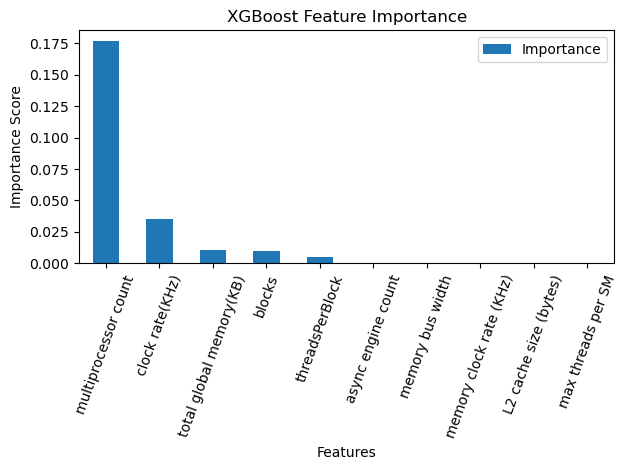

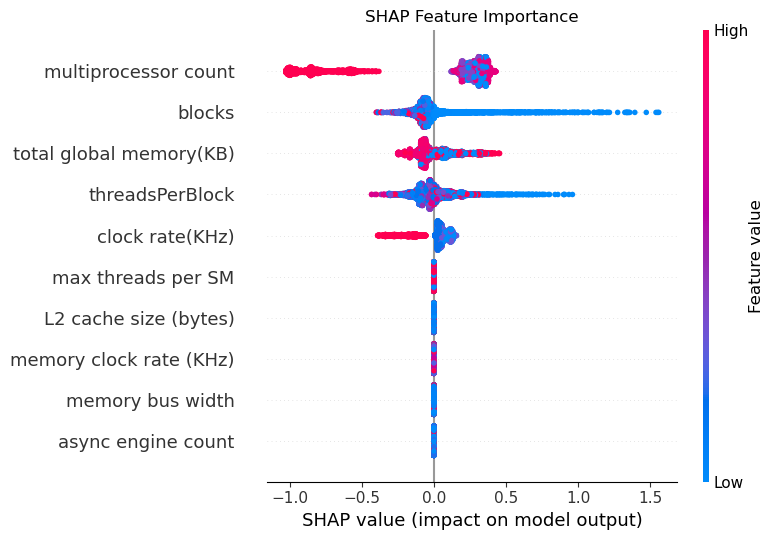

In [247]:
def analyze_feature_importance(model, X_train, exclude, feature_names=None):
    
    if isinstance(exclude, str):
        exclude_idx = feature_names.index(exclude)
    else:
        exclude_idx = exclude
    
    include_names = [name for i, name in enumerate(feature_names) if i != exclude_idx]
    
    importance_values = model.feature_importances_
    importance_dict = {
        name: score for name, score in zip(
            feature_names, 
            importance_values
        ) if name != feature_names[exclude_idx]
    }
    
    importance_df = pd.DataFrame({
        'Feature': list(importance_dict.keys()),
        'Importance': list(importance_dict.values())
    }).sort_values('Importance', ascending=False)
    
    #running shap
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_train)
    
    # exclude 'elements'
    if isinstance(X_train, pd.DataFrame):
        X_train_filtered = X_train.drop(columns=[feature_names[exclude_idx]])
    else:
        X_train_filtered = np.delete(X_train, exclude_idx, axis=1)
    
    shap_values_filtered = np.delete(shap_values, exclude_idx, axis=1)
    
    # mean absolute shap values for each input feature
    # absolute value because we want to measure total impact, positive or negative on the comptue time
    mean_shap = pd.DataFrame({
        'Feature': include_names,
        'SHAP_Importance': np.abs(shap_values_filtered).mean(axis=0)
    }).sort_values('SHAP_Importance', ascending=False)
    

    fig_xgb = plt.figure(figsize=(10, 5))
    importance_df.plot(x='Feature', y='Importance', kind='bar')
    plt.title('XGBoost Feature Importance')
    plt.xlabel('Features')
    plt.ylabel('Importance Score')
    plt.xticks(rotation=70)
    plt.tight_layout()
    
    fig_shap = plt.figure(figsize=(10, 5))
    shap.summary_plot(shap_values_filtered, X_train_filtered, 
                     feature_names=include_names, show=False)
    plt.title('SHAP Feature Importance')
    plt.tight_layout()
    
    return {
        'xgboost_importance': importance_df,
        'shap_importance': mean_shap,
        'shap_values': shap_values_filtered,
        'figure_xgb': fig_xgb,
        'figure_shap': fig_shap
    }

results = analyze_feature_importance(model, X_train, exclude='elements', feature_names=features)

print("\nTop 5 most important features (XGBoost):")
print(results['xgboost_importance'].head())

print("\nTop 5 most important features (SHAP):")
print(results['shap_importance'].head())

plt.show()
